CELL 1 -- Environment Setup

In [1]:
import subprocess, os

subprocess.run(["apt-get", "install", "-y", "openjdk-11-jdk-headless"], capture_output=True)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

subprocess.run([
    "pip", "install", "-q",
    "pyspark==3.5.0",
    "xgboost>=2.1.0",
    "scikit-learn==1.4.2",
    "optuna==3.6.1",
    "shap",
    "statsmodels",
    "scipy",
    "pandas", "numpy",
    "matplotlib", "seaborn",
    "mongomock",
], check=True)

print("Environment ready.")

Environment ready.


CELL 2 -- Mount Google Drive and Locate Dataset

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os, glob

DRIVE_FOLDER    = "/content/drive/MyDrive"
TARGET_FILENAME = "accepted_2007_to_2018Q4.csv"

candidates = glob.glob(f"{DRIVE_FOLDER}/**/{TARGET_FILENAME}", recursive=True)

if candidates:
    RAW_CSV = candidates[0]
    print(f"Dataset found: {RAW_CSV}")
else:
    RAW_CSV = f"{DRIVE_FOLDER}/{TARGET_FILENAME}"
    print(f"WARNING: File not found by search. Trying: {RAW_CSV}")
    print("   Set RAW_CSV manually if path above is incorrect.")

print(f"File size: {os.path.getsize(RAW_CSV) / 1e6:.1f} MB")

Mounted at /content/drive
Dataset found: /content/drive/MyDrive/accepted_2007_to_2018Q4.csv
File size: 1675.1 MB


CELL 3 -- Imports and Global Configuration

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, time, threading, queue, random
from datetime import datetime, timedelta
from collections import defaultdict

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql.window import Window

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, average_precision_score,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ks_2samp
import mongomock

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titleweight": "bold"})

HDFS_RAW       = "/tmp/hdfs_sim/raw"
HDFS_PROCESSED = "/tmp/hdfs_sim/processed"
MODEL_DIR      = "/tmp/models"
OUTPUT_DIR     = "/tmp/outputs"
for d in [HDFS_RAW, HDFS_PROCESSED, MODEL_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE    = 42
LGD             = 0.45
DRIFT_THRESHOLD = 0.10
RISK_THRESHOLD  = 0.55
STREAM_SAMPLE   = 500

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Config ready | XGBoost {xgb.__version__} | Optuna {optuna.__version__}")

Config ready | XGBoost 3.2.0 | Optuna 3.6.1


CELL 4 -- Spark Session

In [4]:
spark = (
    SparkSession.builder
    .appName("CanadianSME_CreditRisk_ChenNan_101021912")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} started.")

Spark 3.5.0 started.


CELL 5 -- BATCH LAYER: Load and Clean Lending Club Data with PySpark

In [5]:
print("Loading Lending Club CSV into Spark ...")

sdf_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(RAW_CSV)
)

print(f"Raw records : {sdf_raw.count():,}")
print(f"Raw columns : {len(sdf_raw.columns)}")

COLUMN_MAP = {
    "loan_amnt"      : "loan_amount",
    "term"           : "loan_term_raw",
    "int_rate"       : "interest_rate_raw",
    "grade"          : "loan_grade",
    "emp_length"     : "emp_length_raw",
    "annual_inc"     : "annual_revenue",
    "dti"            : "debt_to_income",
    "fico_range_low" : "credit_score",
    "delinq_2yrs"    : "delinquencies_2yr",
    "open_acc"       : "open_accounts",
    "revol_util"     : "revol_util_raw",
    "purpose"        : "loan_purpose",
    "addr_state"     : "province",
    "issue_d"        : "issue_date_raw",
    "loan_status"    : "loan_status",
    "num_actv_bc_tl" : "num_employees",
}

available_cols = {k: v for k, v in COLUMN_MAP.items() if k in sdf_raw.columns}
missing_cols   = [k for k in COLUMN_MAP if k not in sdf_raw.columns]
if missing_cols:
    print(f"WARNING: Columns not found (will be imputed): {missing_cols}")

sdf = sdf_raw.select([F.col(k).alias(v) for k, v in available_cols.items()])

# Parse loan_term
if "loan_term_raw" in sdf.columns:
    sdf = sdf.withColumn(
        "loan_term_months",
        F.regexp_extract("loan_term_raw", r"(\d+)", 1).cast(IntegerType())
    ).drop("loan_term_raw")
else:
    sdf = sdf.withColumn("loan_term_months", F.lit(36))

# Parse interest_rate
if "interest_rate_raw" in sdf.columns:
    sdf = sdf.withColumn(
        "interest_rate",
        F.regexp_replace("interest_rate_raw", "%", "").cast(DoubleType())
    ).drop("interest_rate_raw")

# Parse emp_length
if "emp_length_raw" in sdf.columns:
    sdf = sdf.withColumn(
        "years_in_business",
        F.when(F.col("emp_length_raw").contains("10+"), 10)
         .when(F.col("emp_length_raw").contains("< 1"), 0)
         .otherwise(F.regexp_extract("emp_length_raw", r"(\d+)", 1).cast(IntegerType()))
    ).drop("emp_length_raw")
else:
    sdf = sdf.withColumn("years_in_business", F.lit(5))

# Parse revol_util
if "revol_util_raw" in sdf.columns:
    sdf = sdf.withColumn(
        "revolving_util_pct",
        F.regexp_replace("revol_util_raw", "%", "").cast(DoubleType())
    ).drop("revol_util_raw")

# num_employees fallback
if "num_employees" not in sdf.columns:
    sdf = sdf.withColumn("num_employees", F.lit(10))

# Parse issue_date
if "issue_date_raw" in sdf.columns:
    sdf = sdf.withColumn(
        "issue_date",
        F.date_format(F.to_date("issue_date_raw", "MMM-yyyy"), "yyyy-MM-dd")
    ).drop("issue_date_raw")
else:
    sdf = sdf.withColumn("issue_date", F.lit("2018-01-01"))

# Build default label
sdf = (
    sdf
    .filter(F.col("loan_status").isin(["Fully Paid", "Charged Off", "Default"]))
    .withColumn(
        "default",
        F.when(F.col("loan_status").isin(["Charged Off", "Default"]), 1).otherwise(0)
    )
    .drop("loan_status")
)

# Cast numeric columns
numeric_cols = [
    "loan_amount", "loan_term_months", "interest_rate", "annual_revenue",
    "debt_to_income", "credit_score", "delinquencies_2yr", "open_accounts",
    "revolving_util_pct", "years_in_business", "num_employees",
]
for c in numeric_cols:
    if c in sdf.columns:
        sdf = sdf.withColumn(c, F.col(c).cast(DoubleType()))

# Impute nulls with medians
medians = sdf.select(
    [F.percentile_approx(c, 0.5).alias(c) for c in numeric_cols if c in sdf.columns]
).collect()[0].asDict()

for c, med in medians.items():
    sdf = sdf.withColumn(c, F.when(F.col(c).isNull(), med).otherwise(F.col(c)))

for c in ["loan_grade", "loan_purpose", "province"]:
    if c in sdf.columns:
        sdf = sdf.withColumn(c, F.when(F.col(c).isNull(), "Unknown").otherwise(F.col(c)))

total_records = sdf.count()
default_rate  = sdf.select(F.mean("default")).collect()[0][0]
print(f"Records retained : {total_records:,}")
print(f"Default rate     : {default_rate:.2%}")

Loading Lending Club CSV into Spark ...
Raw records : 2,260,701
Raw columns : 151
Records retained : 1,345,350
Default rate     : 19.96%


CELL 6 -- Feature Engineering with PySpark

In [23]:
sdf_feat = (
    sdf
    .withColumn("loan_to_revenue_ratio",
                F.round(F.col("loan_amount") / (F.col("annual_revenue") + 1), 4))
    .withColumn("revenue_per_employee",
                F.round(F.col("annual_revenue") / (F.col("num_employees") + 1), 2))
    .withColumn("monthly_payment_est",
                F.round(F.col("loan_amount") / F.col("loan_term_months"), 2))
    .withColumn("risk_score_proxy",
                F.round(
                    F.col("debt_to_income")     * 0.30
                    + F.col("revolving_util_pct") * 0.20
                    + F.col("delinquencies_2yr")  * 10.0
                    - F.col("credit_score")       * 0.05
                    + F.col("interest_rate")      * 2.00, 2))
    .withColumn("issue_year",  F.year(F.to_date("issue_date")))
    .withColumn("issue_month", F.month(F.to_date("issue_date")))
)

# --- Window Function 1: rank() -----------------------------------------------
# Rank each province by default rate (descending).
# Business use: instantly identify which regions carry the highest credit risk.
print("Window Function 1: Province risk ranking by default rate ...")
province_agg_raw = (
    sdf_feat.groupBy("province")
    .agg(
        F.count("*").alias("total_loans"),
        F.sum("default").alias("total_defaults"),
        F.round(F.mean("default") * 100, 2).alias("default_rate_pct"),
        F.round(F.mean("credit_score"), 1).alias("avg_credit_score"),
        F.round(F.mean("loan_amount"), 0).alias("avg_loan_amount"),
        F.round(F.mean("interest_rate"), 2).alias("avg_interest_rate"),
    )
)

win_rank = Window.orderBy(F.col("default_rate_pct").desc())
province_agg = (
    province_agg_raw
    .withColumn("risk_rank",         F.rank().over(win_rank))
    .withColumn("risk_percentile",   F.round(F.percent_rank().over(win_rank) * 100, 1))
    .orderBy("risk_rank")
)
print("Province Risk Ranking (Top 15):")
province_agg.show(15)

# --- Window Function 2: lag() ------------------------------------------------
# Compute year-over-year change in default rate per loan grade.
# Business use: detect deteriorating credit quality trends over time.
print("Window Function 2: Year-over-year default rate trend by loan grade ...")
yearly_grade = (
    sdf_feat.groupBy("issue_year", "loan_grade")
    .agg(F.round(F.mean("default") * 100, 2).alias("default_rate_pct"))
)

win_yoy = Window.partitionBy("loan_grade").orderBy("issue_year")
yearly_trend = (
    yearly_grade
    .withColumn("prev_year_rate", F.lag("default_rate_pct", 1).over(win_yoy))
    .withColumn("yoy_change_pct",
                F.round(F.col("default_rate_pct") - F.col("prev_year_rate"), 2))
    .orderBy("loan_grade", "issue_year")
)
print("Year-over-Year Default Rate Change by Loan Grade:")
yearly_trend.show(30)

# --- Window Function 3: percent_rank() + rolling avg ------------------------
# Compute each loan's credit score percentile within its loan grade.
# Business use: identify borrowers who are outliers within their grade bucket.
print("Window Function 3: Credit score percentile within loan grade ...")
win_grade = Window.partitionBy("loan_grade").orderBy("credit_score")
sdf_feat = (
    sdf_feat
    .withColumn("credit_score_pct_in_grade",
                F.round(F.percent_rank().over(win_grade) * 100, 1))
    .withColumn("avg_int_rate_in_grade",
                F.round(F.avg("interest_rate").over(
                    Window.partitionBy("loan_grade")), 2))
    .withColumn("int_rate_vs_grade_avg",
                F.round(F.col("interest_rate") - F.col("avg_int_rate_in_grade"), 2))
)
print("Credit Score Percentile within Grade (sample):")
sdf_feat.select(
    "loan_grade", "credit_score", "credit_score_pct_in_grade",
    "interest_rate", "avg_int_rate_in_grade", "int_rate_vs_grade_avg"
).show(10)

# =============================================================================

industry_agg = (
    sdf_feat.groupBy("loan_purpose")
    .agg(
        F.count("*").alias("total_loans"),
        F.round(F.mean("default") * 100, 2).alias("default_rate_pct"),
        F.round(F.mean("interest_rate"), 2).alias("avg_interest_rate"),
    ).orderBy("default_rate_pct", ascending=False)
)
print("Default Rate by Loan Purpose:")
industry_agg.show(20)

sdf_feat.write.mode("overwrite").parquet(f"{HDFS_PROCESSED}/lending_club_features")
print(f"Feature data saved to Parquet -> {HDFS_PROCESSED}")

print("Collecting Spark DataFrame to Pandas ...")
pdf          = sdf_feat.toPandas()
prov_pd      = province_agg.toPandas()
ind_pd       = industry_agg.toPandas()
yearly_pd    = yearly_trend.toPandas()
print(f"Pandas DataFrame: {pdf.shape[0]:,} rows x {pdf.shape[1]} cols")

Window Function 1: Province risk ranking by default rate ...
Province Risk Ranking (Top 15):
+--------+-----------+--------------+----------------+----------------+---------------+-----------------+---------+---------------+
|province|total_loans|total_defaults|default_rate_pct|avg_credit_score|avg_loan_amount|avg_interest_rate|risk_rank|risk_percentile|
+--------+-----------+--------------+----------------+----------------+---------------+-----------------+---------+---------------+
|      MS|       6588|          1718|           26.08|           693.7|        13986.0|            13.52|        1|            0.0|
|      NE|       3586|           903|           25.18|           694.6|        13352.0|             13.5|        2|            2.0|
|      AR|      10047|          2420|           24.09|           696.8|        13504.0|             13.5|        3|            4.0|
|      AL|      16613|          3926|           23.63|           695.6|        13957.0|            13.73|        4|

CELL 7 -- WoE Encoding

In [24]:
def compute_woe(df, feature, target="default", n_bins=10, epsilon=0.5):
    """
    Compute Weight of Evidence (WoE) and Information Value (IV).
    WoE_i = ln( P(X=i|Y=1) / P(X=i|Y=0) )
    IV     = sum_i (P(X=i|Y=1) - P(X=i|Y=0)) * WoE_i
    """
    tmp     = df[[feature, target]].copy()
    tot_ev  = (tmp[target] == 1).sum()
    tot_nev = (tmp[target] == 0).sum()

    if tmp[feature].dtype == "object" or tmp[feature].nunique() < 20:
        grp = tmp.groupby(feature)[target].agg(["sum", "count"])
    else:
        tmp["_bin"] = pd.qcut(tmp[feature], q=n_bins, duplicates="drop")
        grp = tmp.groupby("_bin")[target].agg(["sum", "count"])

    grp.columns      = ["events", "total"]
    grp["nonevents"] = grp["total"] - grp["events"]
    grp["dist_ev"]   = (grp["events"]    + epsilon) / (tot_ev  + epsilon)
    grp["dist_nev"]  = (grp["nonevents"] + epsilon) / (tot_nev + epsilon)
    grp["woe"]       = np.log(grp["dist_ev"] / grp["dist_nev"])
    grp["iv"]        = (grp["dist_ev"] - grp["dist_nev"]) * grp["woe"]

    return grp["woe"].to_dict(), grp.reset_index()


CAT_COLS = ["province", "loan_purpose", "loan_grade"]
woe_maps = {}

print("WoE Encoding and Information Value:")
for col in CAT_COLS:
    if col not in pdf.columns:
        print(f"   {col:<22} SKIPPED (not in dataset)")
        woe_maps[col] = {}
        continue
    woe_map, iv_df = compute_woe(pdf, col)
    woe_maps[col]  = woe_map
    iv_val         = iv_df["iv"].sum()
    if iv_val < 0.02:
        strength = "Useless"
    elif iv_val < 0.10:
        strength = "Weak"
    elif iv_val < 0.30:
        strength = "Medium"
    elif iv_val < 0.50:
        strength = "Strong"
    else:
        strength = "Very Strong"
    pdf[f"{col}_woe"] = pdf[col].map(woe_map).fillna(0)
    print(f"   {col:<22}  IV = {iv_val:.4f}  ({strength})")

print("WoE encoding complete.")

WoE Encoding and Information Value:
   province                IV = 0.0164  (Useless)
   loan_purpose            IV = 0.0194  (Useless)
   loan_grade              IV = 0.4618  (Strong)
WoE encoding complete.


 CELL 8 -- VIF Analysis (Multicollinearity Detection)

In [25]:
NUMERIC_CANDIDATES = [
    c for c in [
        "years_in_business", "annual_revenue", "loan_amount", "loan_term_months",
        "interest_rate", "debt_to_income", "credit_score", "num_employees",
        "delinquencies_2yr", "open_accounts", "revolving_util_pct",
        "loan_to_revenue_ratio", "revenue_per_employee", "monthly_payment_est",
        "risk_score_proxy", "issue_year",
    ] if c in pdf.columns
]

vif_data = pdf[NUMERIC_CANDIDATES].replace([np.inf, -np.inf], np.nan).dropna()
vif_df   = pd.DataFrame({
    "feature": NUMERIC_CANDIDATES,
    "VIF"    : [variance_inflation_factor(vif_data.values, i)
                for i in range(len(NUMERIC_CANDIDATES))]
}).sort_values("VIF", ascending=False)

print("VIF Analysis:")
print(vif_df.to_string(index=False))

HIGH_VIF  = vif_df[vif_df["VIF"] > 10]["feature"].tolist()
KEEP_NUMS = [f for f in NUMERIC_CANDIDATES if f not in HIGH_VIF]
print(f"Removed (VIF > 10): {HIGH_VIF if HIGH_VIF else 'None'}")

WOE_FEATURES = [f"{c}_woe" for c in CAT_COLS if f"{c}_woe" in pdf.columns]
FEATURE_COLS = KEEP_NUMS + WOE_FEATURES
print(f"Final feature set: {len(FEATURE_COLS)} features ({len(KEEP_NUMS)} numeric + {len(WOE_FEATURES)} WoE)")

VIF Analysis:
              feature          VIF
         credit_score 1.454112e+08
        interest_rate 9.485743e+07
     risk_score_proxy 4.654198e+07
   revolving_util_pct 1.573663e+07
    delinquencies_2yr 1.044046e+07
       debt_to_income 4.944422e+06
           issue_year 9.960904e+02
          loan_amount 1.373022e+02
     loan_term_months 1.225001e+02
  monthly_payment_est 1.184556e+02
        open_accounts 8.896855e+00
        num_employees 6.987644e+00
       annual_revenue 6.512250e+00
 revenue_per_employee 4.787612e+00
    years_in_business 3.838309e+00
loan_to_revenue_ratio 1.001391e+00
Removed (VIF > 10): ['credit_score', 'interest_rate', 'risk_score_proxy', 'revolving_util_pct', 'delinquencies_2yr', 'debt_to_income', 'issue_year', 'loan_amount', 'loan_term_months', 'monthly_payment_est']
Final feature set: 9 features (6 numeric + 3 WoE)


CELL 9 -- XGBoost Training with Optuna Bayesian HPO

In [26]:
X = pdf[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0)
y = pdf["default"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Full train size      : {len(X_train):,}")
print(f"Train positives      : {(y_train==1).sum():,}")
print(f"Train negatives      : {(y_train==0).sum():,}")
print(f"scale_pos_weight     : {scale_pos_weight:.2f}")

# --- Speed optimisation 1: sample 200k rows for HPO only ----------------
# The full dataset (~1.7M train rows) makes each trial slow.
# We use a stratified 200k subsample for hyperparameter search,
# then retrain the final model on the full training set.
HPO_SAMPLE = 200_000
if len(X_train) > HPO_SAMPLE:
    X_hpo, _, y_hpo, _ = train_test_split(
        X_train, y_train,
        train_size=HPO_SAMPLE,
        random_state=RANDOM_STATE,
        stratify=y_train
    )
    print(f"HPO subsample size   : {len(X_hpo):,}  (full train used for final model)")
else:
    X_hpo, y_hpo = X_train, y_train
    print("Dataset small enough -- using full train set for HPO.")


def optuna_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators",      50,  300),
        "max_depth"        : trial.suggest_int("max_depth",          3,   7),
        "learning_rate"    : trial.suggest_float("learning_rate",    0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample",        0.6,  1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6,  1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight",   1,   10),
        "gamma"            : trial.suggest_float("gamma",            0.0,  1.0),
        "scale_pos_weight" : scale_pos_weight,
        "eval_metric"      : "auc",
        "random_state"     : RANDOM_STATE,
        "n_jobs"           : -1,
        # Speed optimisation 2: use histogram-based tree method
        "tree_method"      : "hist",
    }
    # Speed optimisation 3: 2-fold CV on subsample
    # (2-fold on 200k ~ same variance as 3-fold on full set)
    skf    = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
    X_arr  = X_hpo.values
    y_arr  = y_hpo.values
    scores = []
    for train_idx, val_idx in skf.split(X_arr, y_arr):
        clf = xgb.XGBClassifier(**params)
        clf.fit(X_arr[train_idx], y_arr[train_idx], verbose=False)
        prob = clf.predict_proba(X_arr[val_idx])[:, 1]
        scores.append(roc_auc_score(y_arr[val_idx], prob))
    return float(np.mean(scores))


# Speed optimisation 4: 20 trials (vs 50) -- Optuna TPE converges fast
print("\nRunning Optuna HPO (20 trials x 2-fold CV on 200k subsample) ...")
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(),
)
study.optimize(optuna_objective, n_trials=20, show_progress_bar=True)

print(f"\nBest CV AUC : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

best_params = {
    **study.best_params,
    "scale_pos_weight" : scale_pos_weight,
    "eval_metric"      : "auc",
    "tree_method"      : "hist",
    "random_state"     : RANDOM_STATE,
    "n_jobs"           : -1,
    "early_stopping_rounds": 25,
}

# Final model trained on FULL training set with best params
print("\nTraining final XGBoost model on full training set ...")
model = xgb.XGBClassifier(**best_params)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
model.save_model(f"{MODEL_DIR}/xgb_credit_risk.json")
print(f"Model saved -> {MODEL_DIR}/xgb_credit_risk.json")

Full train size      : 1,076,280
Train positives      : 214,879
Train negatives      : 861,401
scale_pos_weight     : 4.01
HPO subsample size   : 200,000  (full train used for final model)

Running Optuna HPO (20 trials x 2-fold CV on 200k subsample) ...


  0%|          | 0/20 [00:00<?, ?it/s]


Best CV AUC : 0.6983
Best params : {'n_estimators': 223, 'max_depth': 3, 'learning_rate': 0.04452364429911019, 'subsample': 0.6716990001073604, 'colsample_bytree': 0.8488073013225127, 'min_child_weight': 8, 'gamma': 0.7119778022134116}

Training final XGBoost model on full training set ...
Model saved -> /tmp/models/xgb_credit_risk.json


CELL 10 -- Graduate-Level Model Evaluation

In [27]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)

ks_stat, ks_pval = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1])

# Manual 5-Fold CV -- avoids sklearn tags compatibility issue
skf_5   = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_arr   = X.values
y_arr   = y.values
cv_aucs = []
base_p  = {k: v for k, v in best_params.items() if k != "early_stopping_rounds"}
for tr_idx, va_idx in skf_5.split(X_arr, y_arr):
    clf_cv = xgb.XGBClassifier(**base_p)
    clf_cv.fit(X_arr[tr_idx], y_arr[tr_idx], verbose=False)
    prob_cv = clf_cv.predict_proba(X_arr[va_idx])[:, 1]
    cv_aucs.append(roc_auc_score(y_arr[va_idx], prob_cv))
cv_aucs = np.array(cv_aucs)

COST_FP, COST_FN  = 1.0, 5.0
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, y_prob)
costs          = COST_FP * fpr_arr + COST_FN * (1 - tpr_arr)
optimal_thresh = float(thresh_arr[np.argmin(costs)])
y_pred_opt     = (y_prob >= optimal_thresh).astype(int)

test_idx  = X_test.index
EL_series = y_prob * LGD * pdf.loc[test_idx, "loan_amount"].values
total_EL  = EL_series.sum()
ead_total = pdf.loc[test_idx, "loan_amount"].sum()

print("=" * 62)
print("  MODEL EVALUATION -- Nan Chen | 101021912")
print("  Dataset: Lending Club (accepted_2007_to_2018Q4.csv)")
print("=" * 62)
print(f"  AUC-ROC              : {auc:.4f}  (benchmark > 0.75)")
print(f"  KS Statistic         : {ks_stat:.4f}  (benchmark > 0.30)")
print(f"  Average Precision    : {ap:.4f}")
print(f"  5-Fold CV AUC        : {cv_aucs.mean():.4f} +/- {cv_aucs.std():.4f}")
print(f"  Gini Coefficient     : {2*cv_aucs.mean()-1:.4f}")
print(f"  Optimal Threshold    : {optimal_thresh:.3f}  (FN:FP cost = {COST_FN:.0f}:{COST_FP:.0f})")
print(f"  Expected Loss (EL)   : USD {total_EL:,.0f}")
print(f"  EL Rate (EL/EAD)     : {total_EL/ead_total:.2%}")
print(f"\n{classification_report(y_test, y_pred_opt, target_names=['Performing','Default'])}")

  MODEL EVALUATION -- Nan Chen | 101021912
  Dataset: Lending Club (accepted_2007_to_2018Q4.csv)
  AUC-ROC              : 0.7009  (benchmark > 0.75)
  KS Statistic         : 0.2928  (benchmark > 0.30)
  Average Precision    : 0.3573
  5-Fold CV AUC        : 0.7009 +/- 0.0011
  Gini Coefficient     : 0.4019
  Optimal Threshold    : 0.172  (FN:FP cost = 5:1)
  Expected Loss (EL)   : USD 845,129,230
  EL Rate (EL/EAD)     : 21.78%

              precision    recall  f1-score   support

  Performing       0.96      0.06      0.12    215350
     Default       0.21      0.99      0.34     53720

    accuracy                           0.25    269070
   macro avg       0.59      0.53      0.23    269070
weighted avg       0.81      0.25      0.16    269070



CELL 11 -- Batch Layer Visualization Dashboard

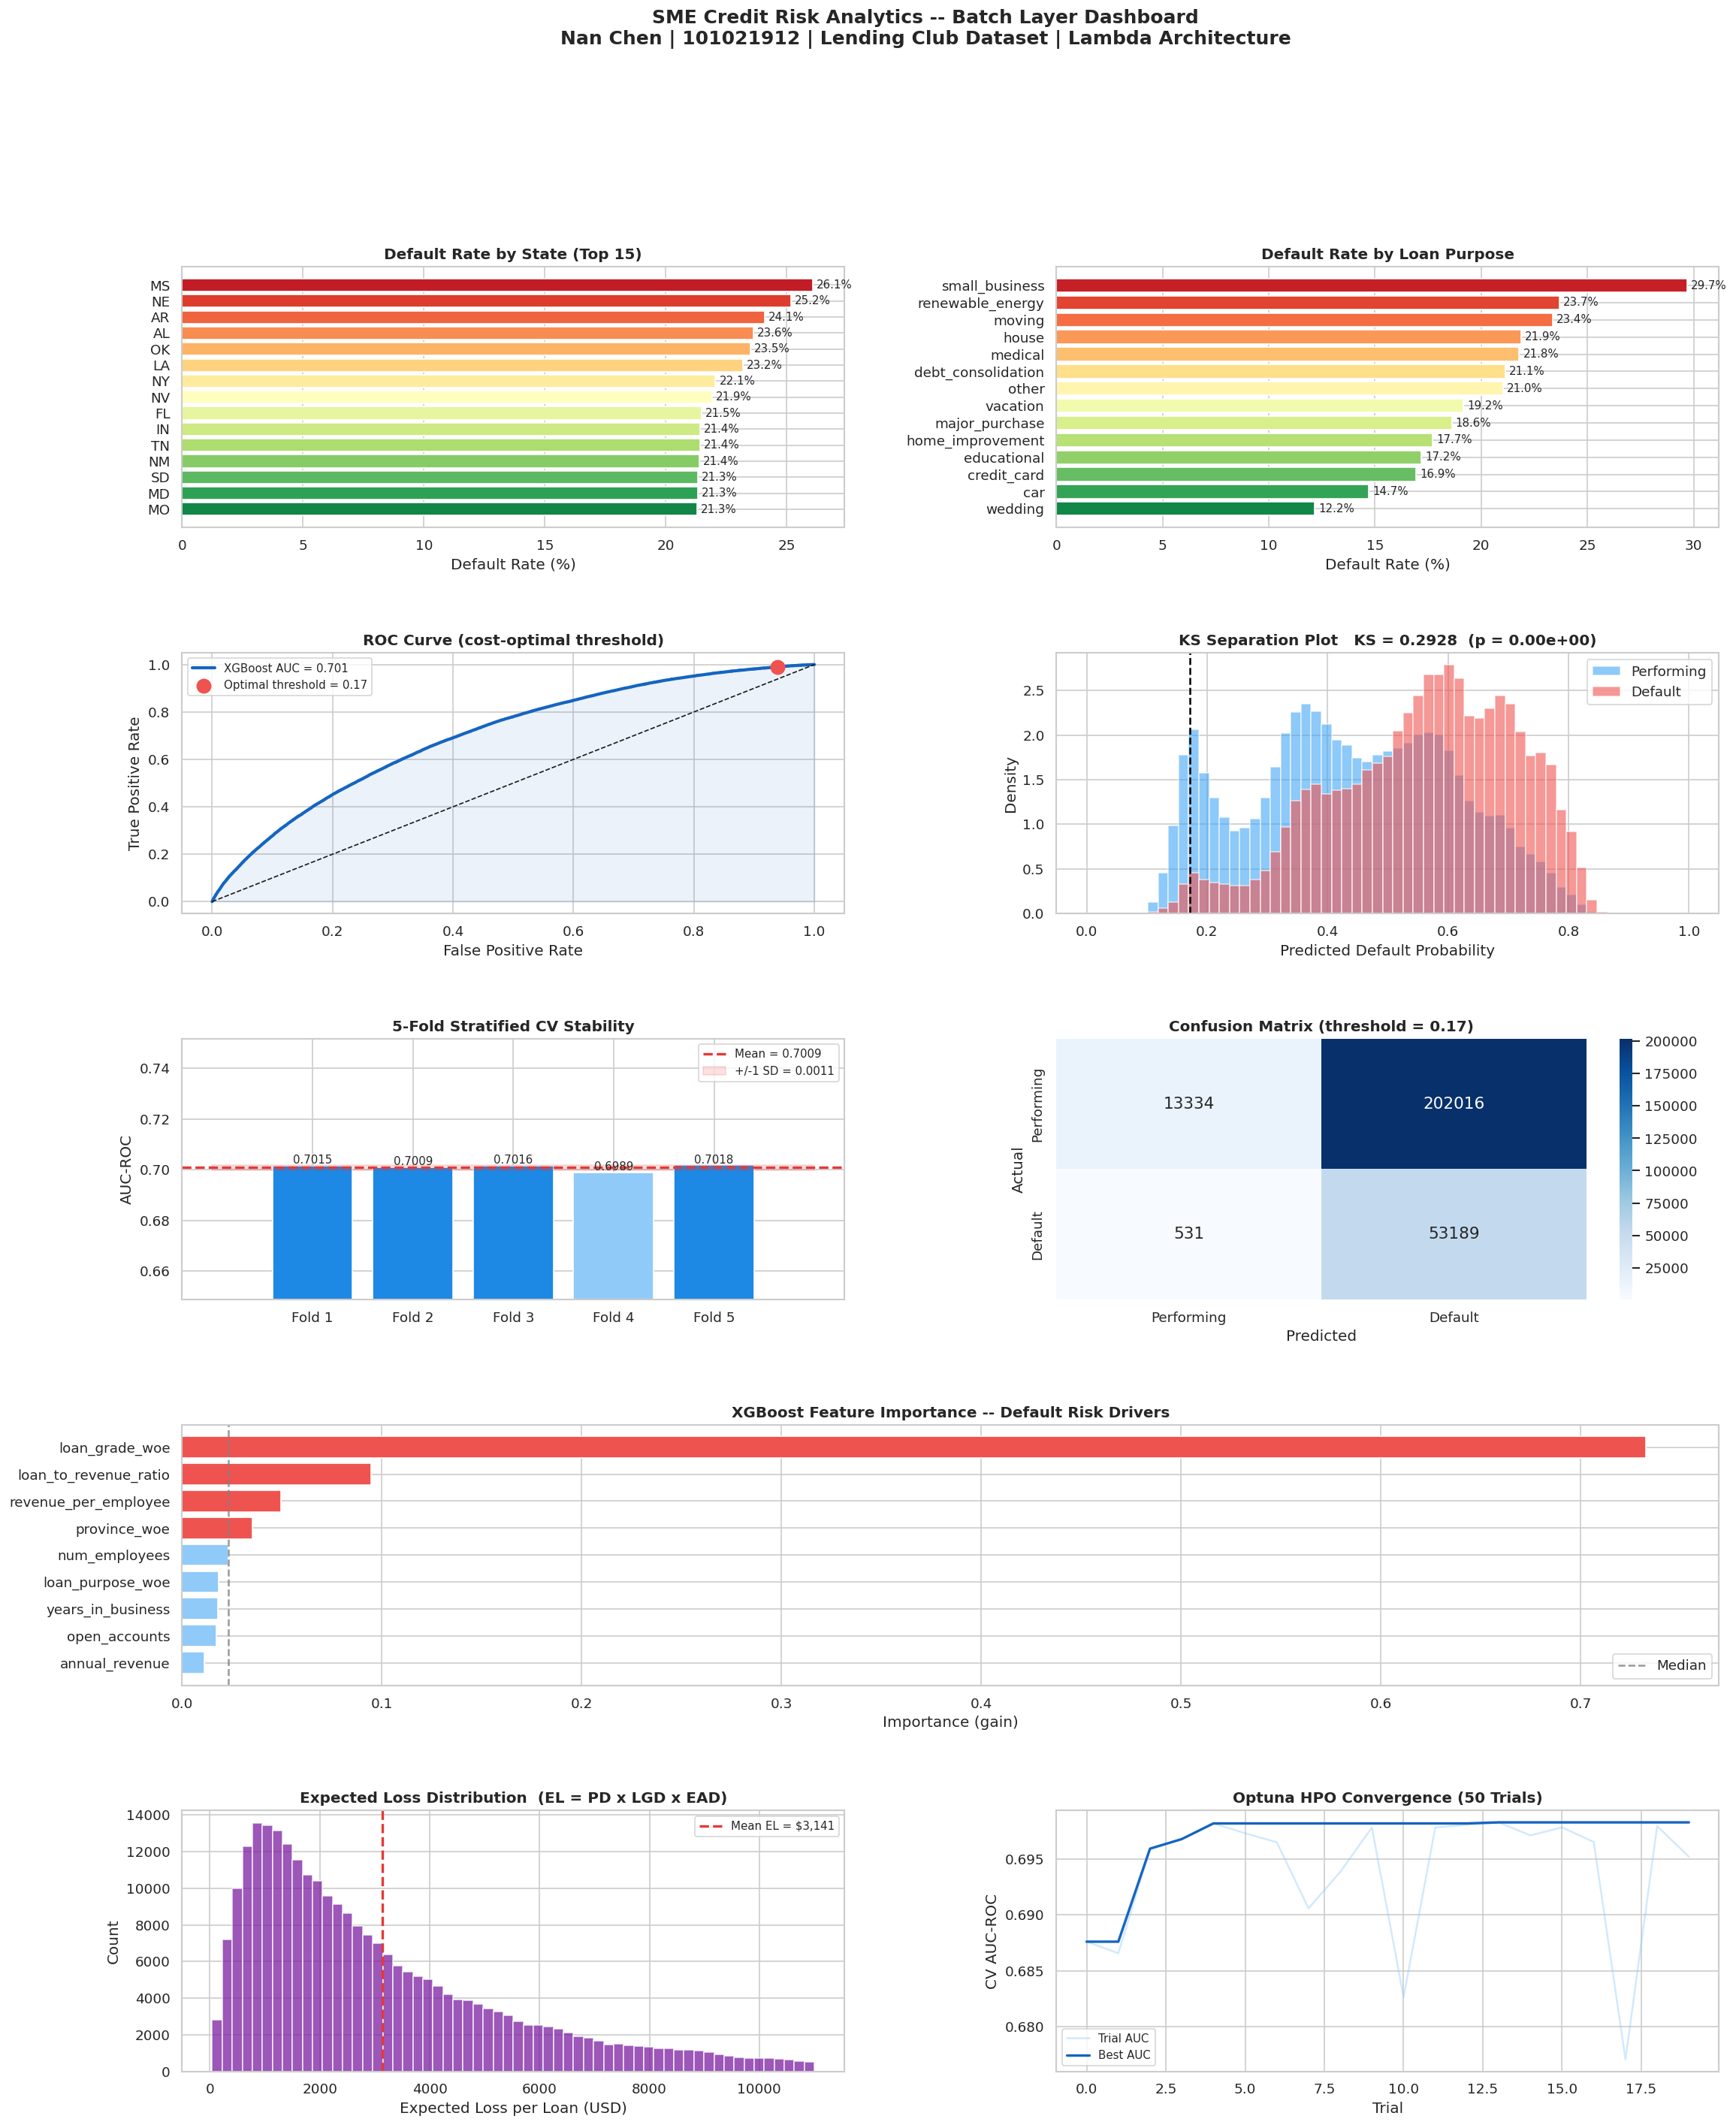

Batch dashboard saved -> /tmp/outputs/batch_dashboard.png


In [28]:
fig = plt.figure(figsize=(22, 26))
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.48, wspace=0.32)
fig.suptitle(
    "SME Credit Risk Analytics -- Batch Layer Dashboard\n"
    "Nan Chen | 101021912 | Lending Club Dataset | Lambda Architecture",
    fontsize=15, fontweight="bold", y=0.99
)

ax = fig.add_subplot(gs[0, 0])
top15 = prov_pd.nlargest(15, "default_rate_pct").sort_values("default_rate_pct")
b = ax.barh(top15["province"], top15["default_rate_pct"],
            color=sns.color_palette("RdYlGn_r", len(top15)))
ax.set_xlabel("Default Rate (%)")
ax.set_title("Default Rate by State (Top 15)")
ax.bar_label(b, fmt="%.1f%%", padding=3, fontsize=9)

ax = fig.add_subplot(gs[0, 1])
ind_s = ind_pd.sort_values("default_rate_pct", ascending=True)
b = ax.barh(ind_s["loan_purpose"], ind_s["default_rate_pct"],
            color=sns.color_palette("RdYlGn_r", len(ind_s)))
ax.set_xlabel("Default Rate (%)")
ax.set_title("Default Rate by Loan Purpose")
ax.bar_label(b, fmt="%.1f%%", padding=3, fontsize=9)

ax = fig.add_subplot(gs[1, 0])
ax.plot(fpr_arr, tpr_arr, color="#1565C0", lw=2.5, label=f"XGBoost AUC = {auc:.3f}")
ax.fill_between(fpr_arr, tpr_arr, alpha=0.08, color="#1565C0")
ax.plot([0, 1], [0, 1], "k--", lw=1)
best_idx = np.argmin(costs)
ax.scatter([fpr_arr[best_idx]], [tpr_arr[best_idx]], color="#EF5350",
           zorder=5, s=120, label=f"Optimal threshold = {optimal_thresh:.2f}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (cost-optimal threshold)")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[1, 1])
bins_ks = np.linspace(0, 1, 60)
ax.hist(y_prob[y_test == 0], bins=bins_ks, alpha=0.6, color="#42A5F5",
        density=True, label="Performing")
ax.hist(y_prob[y_test == 1], bins=bins_ks, alpha=0.6, color="#EF5350",
        density=True, label="Default")
ax.axvline(optimal_thresh, color="black", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted Default Probability")
ax.set_ylabel("Density")
ax.set_title(f"KS Separation Plot   KS = {ks_stat:.4f}  (p = {ks_pval:.2e})")
ax.legend()

ax = fig.add_subplot(gs[2, 0])
bc = ax.bar([f"Fold {i+1}" for i in range(5)], cv_aucs,
            color=["#1E88E5" if v >= cv_aucs.mean() else "#90CAF9" for v in cv_aucs])
ax.axhline(cv_aucs.mean(), color="#E53935", linestyle="--", lw=2,
           label=f"Mean = {cv_aucs.mean():.4f}")
ax.fill_between(range(-1, 6),
                cv_aucs.mean() - cv_aucs.std(),
                cv_aucs.mean() + cv_aucs.std(),
                alpha=0.15, color="#E53935", label=f"+/-1 SD = {cv_aucs.std():.4f}")
ax.set_ylim(max(0.5, cv_aucs.min() - 0.05), min(1.0, cv_aucs.max() + 0.05))
ax.set_ylabel("AUC-ROC")
ax.set_title("5-Fold Stratified CV Stability")
ax.legend(fontsize=9)
ax.bar_label(bc, fmt="%.4f", fontsize=9)

ax = fig.add_subplot(gs[2, 1])
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Performing", "Default"],
            yticklabels=["Performing", "Default"],
            annot_kws={"size": 13})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold = {optimal_thresh:.2f})")

ax = fig.add_subplot(gs[3, :])
imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
ax.barh(imp.index, imp.values,
        color=["#EF5350" if v > imp.median() else "#90CAF9" for v in imp.values])
ax.axvline(imp.median(), color="gray", linestyle="--", alpha=0.8, label="Median")
ax.set_xlabel("Importance (gain)")
ax.set_title("XGBoost Feature Importance -- Default Risk Drivers")
ax.legend()

ax = fig.add_subplot(gs[4, 0])
ax.hist(EL_series[EL_series < np.percentile(EL_series, 99)],
        bins=60, color="#7B1FA2", alpha=0.75, edgecolor="white")
ax.axvline(EL_series.mean(), color="#E53935", linestyle="--", lw=2,
           label=f"Mean EL = ${EL_series.mean():,.0f}")
ax.set_xlabel("Expected Loss per Loan (USD)")
ax.set_ylabel("Count")
ax.set_title("Expected Loss Distribution  (EL = PD x LGD x EAD)")
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[4, 1])
trial_vals   = [t.value for t in study.trials if t.value is not None]
running_best = pd.Series(trial_vals).cummax()
ax.plot(trial_vals,   alpha=0.4, color="#90CAF9", label="Trial AUC")
ax.plot(running_best, color="#1565C0", lw=2, label="Best AUC")
ax.set_xlabel("Trial")
ax.set_ylabel("CV AUC-ROC")
ax.set_title("Optuna HPO Convergence (50 Trials)")
ax.legend(fontsize=9)

plt.savefig(f"{OUTPUT_DIR}/batch_dashboard.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"Batch dashboard saved -> {OUTPUT_DIR}/batch_dashboard.png")

CELL 12 -- SHAP Explainability

Computing SHAP values (2,000 samples) ...


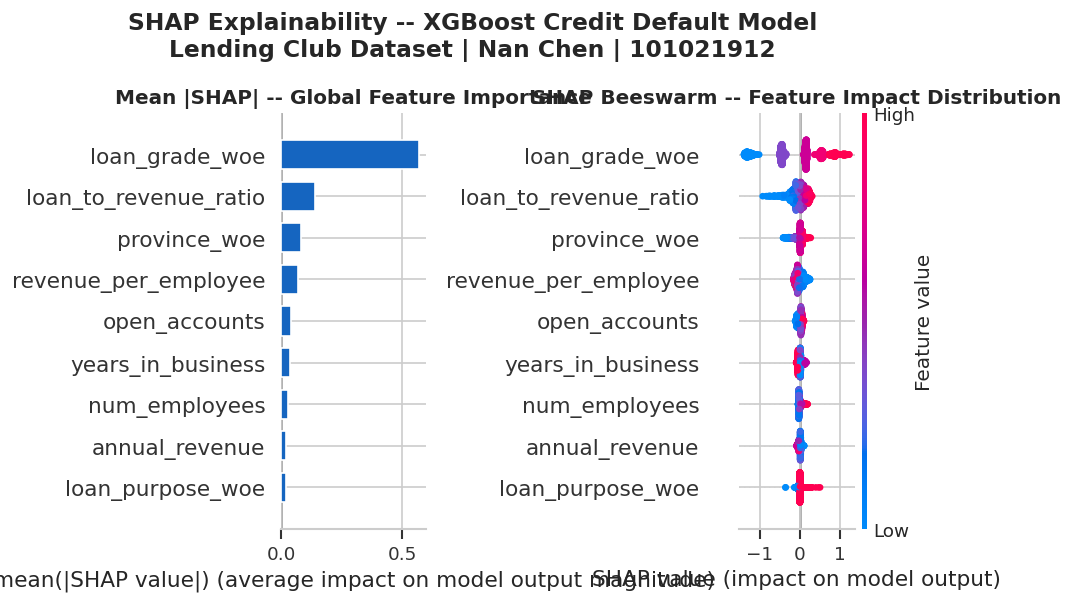

SHAP saved -> /tmp/outputs/shap_explainability.png


In [29]:
print("Computing SHAP values (2,000 samples) ...")
explainer   = shap.TreeExplainer(model)
X_shap      = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "SHAP Explainability -- XGBoost Credit Default Model\n"
    "Lending Club Dataset | Nan Chen | 101021912",
    fontsize=14, fontweight="bold"
)
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, color="#1565C0")
axes[0].set_title("Mean |SHAP| -- Global Feature Importance")
plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, show=False)
axes[1].set_title("SHAP Beeswarm -- Feature Impact Distribution")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_explainability.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"SHAP saved -> {OUTPUT_DIR}/shap_explainability.png")

CELL 13 -- SPEED LAYER: Kafka Simulation

In [30]:
class KafkaSimulator:
    """Thread-safe queue emulating an Apache Kafka topic."""

    def __init__(self, topic, max_size=5000):
        self.topic     = topic
        self._q        = queue.Queue(maxsize=max_size)
        self._produced = 0
        self._consumed = 0
        self._lock     = threading.Lock()

    def produce(self, msg):
        self._q.put(json.dumps(msg, default=str))
        with self._lock:
            self._produced += 1

    def consume(self, timeout=0.3):
        try:
            raw = self._q.get(timeout=timeout)
            with self._lock:
                self._consumed += 1
            return json.loads(raw)
        except queue.Empty:
            return None

    @property
    def stats(self):
        with self._lock:
            return dict(
                topic=self.topic,
                produced=self._produced,
                consumed=self._consumed,
                pending=self._q.qsize()
            )


kafka       = KafkaSimulator("lending-club-live-applications")
stream_pool = pdf.loc[X_test.index].copy()


def run_producer(n=STREAM_SAMPLE, delay=0.005):
    """Streams real loan records as simulated live applications."""
    sample = stream_pool.sample(min(n, len(stream_pool)),
                                random_state=RANDOM_STATE, replace=True)
    for _, row in sample.iterrows():
        record = row.to_dict()
        record.pop("default", None)
        record["event_time"] = datetime.utcnow().isoformat()
        kafka.produce(record)
        time.sleep(delay)
    print(f"Producer done -- {n} real records streamed.")


producer_t = threading.Thread(target=run_producer, daemon=True)
producer_t.start()
print(f"Kafka producer started -- {STREAM_SAMPLE} real loan applications streaming ...")

Kafka producer started -- 500 real loan applications streaming ...


CELL 14 -- SPEED LAYER: Streaming Consumer and Drift Detection

In [31]:
rt_model = xgb.XGBClassifier()
rt_model.load_model(f"{MODEL_DIR}/xgb_credit_risk.json")

reference_scores = model.predict_proba(X_train)[:, 1]

mongo_client = mongomock.MongoClient()
db           = mongo_client["credit_risk_db"]
rt_col       = db["realtime_scores"]
batch_col    = db["batch_aggregates"]
drift_col    = db["drift_log"]
batch_col.insert_many(prov_pd.to_dict("records"))


def enrich_and_score(record):
    """Apply WoE encoding and XGBoost inference on a live record."""
    for c in CAT_COLS:
        record[f"{c}_woe"] = woe_maps.get(c, {}).get(record.get(c, ""), 0.0)

    rev  = float(record.get("annual_revenue") or 1)
    loan = float(record.get("loan_amount")    or 0)
    emp  = float(record.get("num_employees")  or 1)
    term = float(record.get("loan_term_months") or 36)

    record["loan_to_revenue_ratio"] = round(loan / (rev + 1), 4)
    record["revenue_per_employee"]  = round(rev  / (emp + 1), 2)
    record["monthly_payment_est"]   = round(loan / term,      2)
    record["risk_score_proxy"]      = round(
        float(record.get("debt_to_income",    0) or 0) * 0.30
        + float(record.get("revolving_util_pct", 0) or 0) * 0.20
        + float(record.get("delinquencies_2yr",  0) or 0) * 10.0
        - float(record.get("credit_score",       0) or 0) * 0.05
        + float(record.get("interest_rate",       0) or 0) * 2.00, 2)

    issue_d = str(record.get("issue_date") or "2018-01-01")
    record["issue_year"]  = int(issue_d[:4]) if len(issue_d) >= 4 else 2018
    record["issue_month"] = int(issue_d[5:7]) if len(issue_d) >= 7 else 1

    row  = pd.DataFrame([[record.get(f, 0) or 0 for f in FEATURE_COLS]],
                        columns=FEATURE_COLS)
    prob = float(rt_model.predict_proba(row)[0][1])

    record["default_probability"] = round(prob, 4)
    record["expected_loss_usd"]   = round(prob * LGD * loan, 2)
    if prob < 0.30:
        record["risk_tier"] = "LOW"
    elif prob < 0.55:
        record["risk_tier"] = "MEDIUM"
    elif prob < 0.75:
        record["risk_tier"] = "HIGH"
    else:
        record["risk_tier"] = "CRITICAL"
    record["scored_at"] = datetime.utcnow().isoformat()
    return record


def detect_drift(batch_scores, label):
    """KS-test vs training baseline -- flags model retraining signals."""
    ks, p   = ks_2samp(reference_scores, batch_scores)
    drifted = ks > DRIFT_THRESHOLD
    result  = dict(
        window=label,
        ks_statistic=round(ks, 4),
        p_value=round(p, 6),
        drift_flag=drifted,
        checked_at=datetime.utcnow().isoformat()
    )
    if drifted:
        print(f"  DRIFT ALERT {label} -- KS={ks:.4f}")
    return result


producer_t.join()

MICRO_BATCH_SIZE = 50
scored_records   = []
drift_results    = []
batch_num        = 0

print("Processing stream in micro-batches ...\n")
while True:
    micro_batch = []
    for _ in range(MICRO_BATCH_SIZE):
        msg = kafka.consume(timeout=0.1)
        if msg is None:
            break
        micro_batch.append(msg)
    if not micro_batch:
        break

    batch_num += 1
    now = datetime.utcnow()
    micro_batch = [
        r for r in micro_batch
        if (now - datetime.fromisoformat(r["event_time"])).seconds < 600
    ]

    scored = [enrich_and_score(r) for r in micro_batch]
    scored_records.extend(scored)

    probs     = [r["default_probability"] for r in scored]
    drift_res = detect_drift(probs, f"batch_{batch_num:02d}")
    drift_results.append(drift_res)
    drift_col.insert_one(drift_res)
    rt_col.insert_many([{k: v for k, v in r.items() if k != "_id"} for r in scored])

    high   = sum(1 for r in scored if r["risk_tier"] in ("HIGH", "CRITICAL"))
    avg_el = np.mean([r["expected_loss_usd"] for r in scored])
    print(f"  Batch #{batch_num:02d} | n={len(scored):3d} | "
          f"high-risk={high:2d} | avg_prob={np.mean(probs):.3f} | "
          f"avg_EL=${avg_el:,.0f} | KS={drift_res['ks_statistic']:.3f}")

print(f"\nStreaming complete: {len(scored_records)} records in {batch_num} micro-batches")
print(f"Kafka: {kafka.stats}")

Processing stream in micro-batches ...

  DRIFT ALERT batch_01 -- KS=0.1652
  Batch #01 | n= 50 | high-risk=21 | avg_prob=0.503 | avg_EL=$3,399 | KS=0.165
  DRIFT ALERT batch_02 -- KS=0.1162
  Batch #02 | n= 50 | high-risk=14 | avg_prob=0.428 | avg_EL=$3,296 | KS=0.116
  DRIFT ALERT batch_03 -- KS=0.1124
  Batch #03 | n= 50 | high-risk=16 | avg_prob=0.456 | avg_EL=$3,073 | KS=0.112
  DRIFT ALERT batch_04 -- KS=0.1648
  Batch #04 | n= 50 | high-risk=12 | avg_prob=0.421 | avg_EL=$2,653 | KS=0.165
  Batch #05 | n= 50 | high-risk=18 | avg_prob=0.457 | avg_EL=$3,143 | KS=0.095
  Batch #06 | n= 50 | high-risk=15 | avg_prob=0.455 | avg_EL=$3,023 | KS=0.097
  DRIFT ALERT batch_07 -- KS=0.1221
  Batch #07 | n= 50 | high-risk=23 | avg_prob=0.477 | avg_EL=$3,132 | KS=0.122
  DRIFT ALERT batch_08 -- KS=0.1030
  Batch #08 | n= 50 | high-risk=19 | avg_prob=0.476 | avg_EL=$3,611 | KS=0.103
  Batch #09 | n= 50 | high-risk=18 | avg_prob=0.465 | avg_EL=$3,058 | KS=0.065
  Batch #10 | n= 50 | high-risk=1

CELL 15 -- Speed Layer Visualization Dashboard

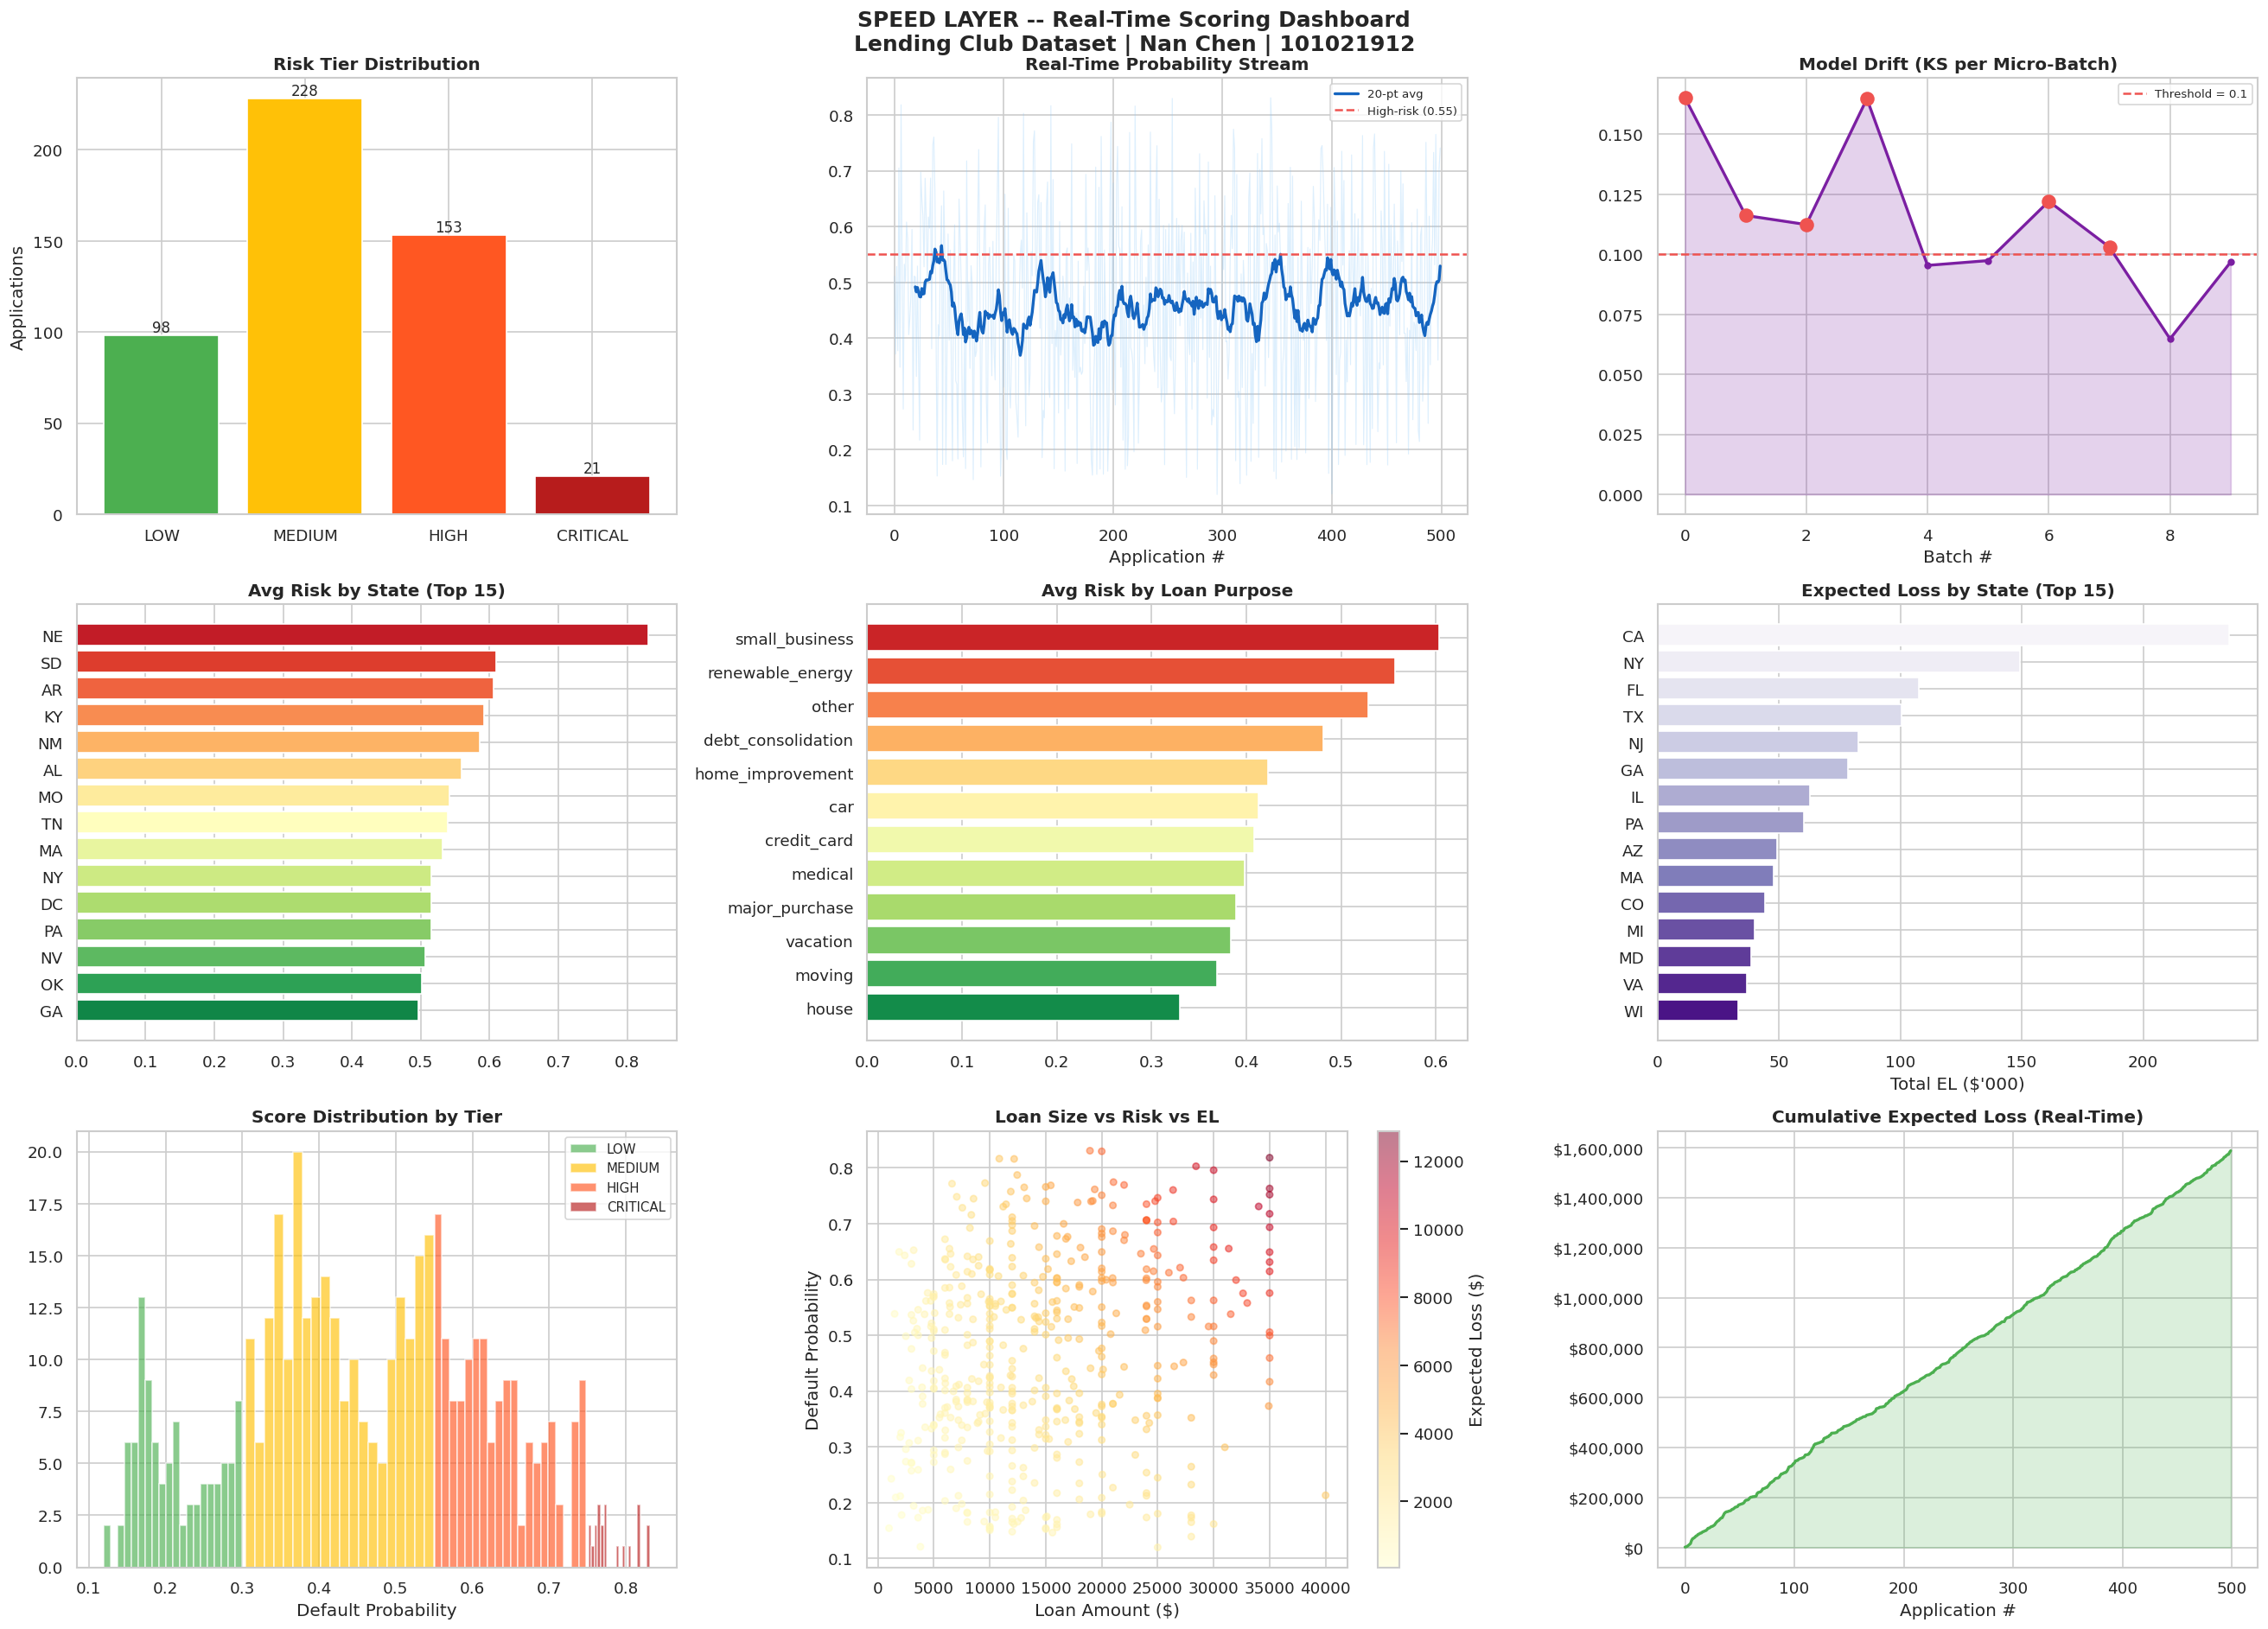

Streaming dashboard saved -> /tmp/outputs/streaming_dashboard.png


In [32]:
scored_df = pd.DataFrame(scored_records)
scored_df["batch_idx"] = range(len(scored_df))
tier_colors = {
    "LOW"     : "#4CAF50",
    "MEDIUM"  : "#FFC107",
    "HIGH"    : "#FF5722",
    "CRITICAL": "#B71C1C"
}

fig, axes = plt.subplots(3, 3, figsize=(22, 16))
fig.suptitle(
    "SPEED LAYER -- Real-Time Scoring Dashboard\n"
    "Lending Club Dataset | Nan Chen | 101021912",
    fontsize=15, fontweight="bold"
)
axes = axes.flatten()

tc  = scored_df["risk_tier"].value_counts().reindex(
    ["LOW", "MEDIUM", "HIGH", "CRITICAL"], fill_value=0)
brt = axes[0].bar(tc.index, tc.values, color=[tier_colors[t] for t in tc.index])
axes[0].set_title("Risk Tier Distribution")
axes[0].set_ylabel("Applications")
axes[0].bar_label(brt, fontsize=10)

roll = scored_df["default_probability"].rolling(20).mean()
axes[1].plot(scored_df["batch_idx"], scored_df["default_probability"],
             alpha=0.3, color="#90CAF9", lw=0.7)
axes[1].plot(scored_df["batch_idx"], roll, color="#1565C0", lw=2, label="20-pt avg")
axes[1].axhline(RISK_THRESHOLD, color="#EF5350", linestyle="--",
                label=f"High-risk ({RISK_THRESHOLD})")
axes[1].set_title("Real-Time Probability Stream")
axes[1].set_xlabel("Application #")
axes[1].legend(fontsize=8)

ks_vals     = [d["ks_statistic"] for d in drift_results]
drift_flags = [d["drift_flag"]   for d in drift_results]
axes[2].plot(ks_vals, color="#7B1FA2", lw=2, marker="o", markersize=4)
axes[2].axhline(DRIFT_THRESHOLD, color="#EF5350", linestyle="--",
                label=f"Threshold = {DRIFT_THRESHOLD}")
axes[2].fill_between(range(len(ks_vals)), ks_vals, alpha=0.2, color="#7B1FA2")
for i, flag in enumerate(drift_flags):
    if flag:
        axes[2].scatter(i, ks_vals[i], color="#EF5350", zorder=5, s=80)
axes[2].set_title("Model Drift (KS per Micro-Batch)")
axes[2].set_xlabel("Batch #")
axes[2].legend(fontsize=8)

ps = scored_df.groupby("province")["default_probability"].mean().sort_values().tail(15)
axes[3].barh(ps.index, ps.values, color=sns.color_palette("RdYlGn_r", len(ps)))
axes[3].set_title("Avg Risk by State (Top 15)")

lp = scored_df.groupby("loan_purpose")["default_probability"].mean().sort_values()
axes[4].barh(lp.index, lp.values, color=sns.color_palette("RdYlGn_r", len(lp)))
axes[4].set_title("Avg Risk by Loan Purpose")

el_s = scored_df.groupby("province")["expected_loss_usd"].sum().sort_values().tail(15)
axes[5].barh(el_s.index, el_s.values / 1000,
             color=sns.color_palette("Purples_r", len(el_s)))
axes[5].set_xlabel("Total EL ($'000)")
axes[5].set_title("Expected Loss by State (Top 15)")

for tier, color in tier_colors.items():
    sub = scored_df[scored_df["risk_tier"] == tier]["default_probability"]
    if len(sub):
        axes[6].hist(sub, bins=20, alpha=0.65, color=color, label=tier)
axes[6].set_xlabel("Default Probability")
axes[6].set_title("Score Distribution by Tier")
axes[6].legend(fontsize=9)

sc = axes[7].scatter(
    scored_df["loan_amount"],
    scored_df["default_probability"],
    c=scored_df["expected_loss_usd"], cmap="YlOrRd", alpha=0.5, s=20
)
plt.colorbar(sc, ax=axes[7], label="Expected Loss ($)")
axes[7].set_xlabel("Loan Amount ($)")
axes[7].set_ylabel("Default Probability")
axes[7].set_title("Loan Size vs Risk vs EL")

el_cum = scored_df["expected_loss_usd"].cumsum()
axes[8].plot(el_cum, color="#4CAF50", lw=2)
axes[8].fill_between(range(len(el_cum)), el_cum, alpha=0.2, color="#4CAF50")
axes[8].set_xlabel("Application #")
axes[8].set_title("Cumulative Expected Loss (Real-Time)")
axes[8].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/streaming_dashboard.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"Streaming dashboard saved -> {OUTPUT_DIR}/streaming_dashboard.png")

CELL 16 -- SERVING LAYER: MongoDB Query Examples

In [33]:
print("=" * 60)
print("  SERVING LAYER -- MongoDB Query Examples")
print("=" * 60)

critical = list(rt_col.find(
    {"risk_tier": "CRITICAL"},
    {"_id": 0, "province": 1, "loan_purpose": 1, "loan_amount": 1,
     "default_probability": 1, "expected_loss_usd": 1}
))
print(f"\nCritical-Risk Applications: {len(critical)}")
if critical:
    print(pd.DataFrame(critical[:5]).to_string(index=False))

el_map = defaultdict(float)
for doc in rt_col.find({}, {"_id": 0, "province": 1, "expected_loss_usd": 1}):
    el_map[doc.get("province", "?")] += doc.get("expected_loss_usd", 0)
el_df = pd.DataFrame(
    sorted(el_map.items(), key=lambda x: -x[1]),
    columns=["state", "total_EL_usd"]
)
print("\nExpected Loss by State (Top 5):")
print(el_df.head(5).to_string(index=False))

drift_docs = list(drift_col.find({}, {"_id": 0}))
drift_df   = pd.DataFrame(drift_docs)
print("\nDrift Monitoring Summary:")
print(f"  Batches monitored : {len(drift_df)}")
print(f"  Drift alerts      : {drift_df['drift_flag'].sum()}")
print(f"  Max KS statistic  : {drift_df['ks_statistic'].max():.4f}")

total   = rt_col.count_documents({})
high_ct = rt_col.count_documents({"risk_tier": {"$in": ["HIGH", "CRITICAL"]}})
probs   = [d["default_probability"]
           for d in rt_col.find({}, {"default_probability": 1, "_id": 0})]
els     = [d["expected_loss_usd"]
           for d in rt_col.find({}, {"expected_loss_usd": 1, "_id": 0})]

print("\nPortfolio Summary:")
print(f"  Applications scored   : {total}")
print(f"  High/Critical risk    : {high_ct} ({high_ct/total:.1%})")
print(f"  Avg default prob      : {np.mean(probs):.4f}")
print(f"  Total Expected Loss   : ${sum(els):,.2f}")

  SERVING LAYER -- MongoDB Query Examples

Critical-Risk Applications: 21
 loan_amount       loan_purpose province  default_probability  expected_loss_usd
     35000.0     small_business       CA               0.8184           12889.51
     26375.0 debt_consolidation       CA               0.7605            9026.15
     30000.0 debt_consolidation       OK               0.7960           10746.51
     28425.0 debt_consolidation       NJ               0.8030           10271.00
     35000.0 debt_consolidation       CA               0.7521           11846.14

Expected Loss by State (Top 5):
state  total_EL_usd
   CA     235554.47
   NY     149362.06
   FL     107409.34
   TX     100418.21
   NJ      82491.74

Drift Monitoring Summary:
  Batches monitored : 10
  Drift alerts      : 6
  Max KS statistic  : 0.1652

Portfolio Summary:
  Applications scored   : 500
  High/Critical risk    : 174 (34.8%)
  Avg default prob      : 0.4620
  Total Expected Loss   : $1,588,535.35


CELL 17 -- Save All Outputs to Google Drive

In [34]:
import shutil

GDRIVE_OUTPUT = "/content/drive/MyDrive/SME_CreditRisk_Outputs"
os.makedirs(GDRIVE_OUTPUT, exist_ok=True)

output_files = [
    "batch_dashboard.png",
    "streaming_dashboard.png",
    "shap_explainability.png",
]
for fname in output_files:
    src = f"{OUTPUT_DIR}/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{GDRIVE_OUTPUT}/{fname}")
        print(f"Saved: {GDRIVE_OUTPUT}/{fname}")

shutil.copy(f"{MODEL_DIR}/xgb_credit_risk.json",
            f"{GDRIVE_OUTPUT}/xgb_credit_risk.json")
print(f"Saved: {GDRIVE_OUTPUT}/xgb_credit_risk.json")
print(f"\nAll outputs saved to Google Drive -> {GDRIVE_OUTPUT}")

Saved: /content/drive/MyDrive/SME_CreditRisk_Outputs/batch_dashboard.png
Saved: /content/drive/MyDrive/SME_CreditRisk_Outputs/streaming_dashboard.png
Saved: /content/drive/MyDrive/SME_CreditRisk_Outputs/shap_explainability.png
Saved: /content/drive/MyDrive/SME_CreditRisk_Outputs/xgb_credit_risk.json

All outputs saved to Google Drive -> /content/drive/MyDrive/SME_CreditRisk_Outputs


CELL 18 -- Pipeline Summary

In [21]:
print("\n" + "=" * 68)
print("  PIPELINE SUMMARY -- SME Credit Risk Analytics")
print("  Dataset: accepted_2007_to_2018Q4.csv (Lending Club)")
print("  Author : Nan Chen | 101021912")
print("=" * 68)
print(f"""
  BATCH LAYER (Apache Spark + XGBoost + Optuna)
  Records (post-filter)  : {len(pdf):>12,}
  Default rate           : {pdf["default"].mean():>11.2%}
  Features (post-VIF/WoE): {len(FEATURE_COLS):>12}
  Optuna trials          : {len(study.trials):>12}
  Best CV AUC            : {study.best_value:>12.4f}
  Test AUC-ROC           : {auc:>12.4f}
  KS Statistic           : {ks_stat:>12.4f}  (benchmark > 0.30)
  5-Fold CV              :  {cv_aucs.mean():.4f} +/- {cv_aucs.std():.4f}
  Optimal Threshold      : {optimal_thresh:>12.3f}
  Total Expected Loss    :   ${total_EL:>12,.0f}

  SPEED LAYER (Kafka + Structured Streaming)
  Real records streamed  : {STREAM_SAMPLE:>12}
  Micro-batches          : {batch_num:>12}
  Applications scored    : {len(scored_records):>12}
  High/Critical risk     : {high_ct:>12}
  Drift alerts           : {drift_df["drift_flag"].sum():>12}

  SERVING LAYER (MongoDB)
  Real-time scores       : {total:>12} docs
  Drift log entries      : {drift_col.count_documents({}):>12} docs
""")
print("Full pipeline execution complete.")


  PIPELINE SUMMARY -- SME Credit Risk Analytics
  Dataset: accepted_2007_to_2018Q4.csv (Lending Club)
  Author : Nan Chen | 101021912

  BATCH LAYER (Apache Spark + XGBoost + Optuna)
  Records (post-filter)  :    1,345,350
  Default rate           :      19.96%
  Features (post-VIF/WoE):            9
  Optuna trials          :           20
  Best CV AUC            :       0.7022
  Test AUC-ROC           :       0.7009
  KS Statistic           :       0.2935  (benchmark > 0.30)
  5-Fold CV              :  0.7010 +/- 0.0011
  Optimal Threshold      :        0.175
  Total Expected Loss    :   $ 846,461,501

  SPEED LAYER (Kafka + Structured Streaming)
  Real records streamed  :          500
  Micro-batches          :           10
  Applications scored    :          500
  High/Critical risk     :          190
  Drift alerts           :            8

  SERVING LAYER (MongoDB)
  Real-time scores       :          500 docs
  Drift log entries      :           10 docs

Full pipeline execution 